# 03 · FunnyBirds MCBM — does minimality create grounding?

Notebook 02 established that a standard CBM can report the wrong visible part under controlled swaps. MCBM changes the representation objective, so we now ask a precise question: does compressing each internal slot `z_j` make it depend on the correct pixels?

We do not assume that “less information in `z_j`” means “information came from part `j`.” Those are different properties.


In [1]:
import os, json, re, glob
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
CURATED = Path(os.environ["CURATED_DATA"]); CWD = Path.cwd(); REPO = CWD if (CWD/"analysis").is_dir() else CWD.parent
import sys; sys.path.insert(0, str(REPO/"analysis"))
try:
    from plotting import set_paper_style, PALETTE; set_paper_style()
    CBM_C, MCBM_C = PALETTE["CBM"], PALETTE["MCBM"]
except Exception:
    CBM_C, MCBM_C = "#0072B2", "#D55E00"
plt.rcParams["figure.dpi"]=120
EPS = 1e-3
def parse_stem(stem):
    m=re.match(r"^funnybirds-(vanilla|cbm|mcbm)(?:-g([0-9p]+))?-s(\d+)$", stem)
    if not m: return None
    gamma=float(m.group(2).replace("p",".")) if m.group(2) else np.nan
    return m.group(1), gamma, int(m.group(3))
def need(p, how):
    ok=Path(p).exists()
    if not ok: print(f"[pending] {p}\n  produce it:  {how}")
    return ok
# ---- seed-aware grounding loaders ----
def load_grounding(prefix):
    """All seeds for a config prefix -> one df with a 'seed' column (None if absent)."""
    fs = sorted(glob.glob(str(CURATED/"grounding"/f"{prefix}-s*.parquet")))
    if not fs: return None
    out=[]
    for f in fs:
        d=pd.read_parquet(f); d["seed"]=int(re.search(r"-s(\d+)\.parquet$", f).group(1)); out.append(d)
    return pd.concat(out, ignore_index=True)
def per_part_seedagg(df, visible_only=True):
    """per (seed,part) retained_frac -> per-part mean/std/count across seeds."""
    d = df[df["changed_frac"]>EPS] if (visible_only and "changed_frac" in df.columns) else df
    g = d.groupby(["seed","part"]).agg(pi=("p_intact","mean"), pr=("p_removed","mean"))
    g["rf"] = g.pr/g.pi
    return g["rf"].groupby("part").agg(["mean","std","count"])


## Model definitions and variables

Both models compute `x → z → (c_preds, y_pred)` with 26 scalar slots `z_j`.

CBM minimizes

`L_CBM = L_y + β L_c`,

where `L_y` is species cross-entropy and `L_c` is the sum of concept losses.

MCBM minimizes

`L_MCBM = L_y + β L_c + γ L_z`,

`L_z = Σ_j 0.2 mean((z_j − (6c_j−3))²)`.

Thus `c_j=1` pulls `z_j` toward `+3`; `c_j=0` pulls it toward `−3`. Training also adds Gaussian noise before the concept and species heads.

**Minimality** means that images sharing the same label `c_j` should produce nearly the same `z_j`, removing image details not needed to state `c_j`.

It can reduce stored interconcept information—for example, wing detail retained inside `z_tail`. It does **not** force `z_tail` to read tail pixels. A body-based rule that outputs exactly `+3` for the correct tail label satisfies minimality perfectly.

Likewise, tail pixels could be used to compute `z_beak`; if they produce the correct `±3` beak label, this loss does not detect the wrong input source.

Quantities used below:

- `margin = z_donor,cf − z_source,cf`;
- `ordering_correct = 1[margin>0]`;
- `donor_shift = z_donor,cf − z_donor,orig`;
- `gap_closed = donor_shift / (z_source,orig − z_donor,orig)`.

`gap_closed` is normalized: it reports the fraction of that model's own original donor deficit that was closed, allowing comparison across different raw `z` scales.


## 1 · Did `γ` actually change the representation?

A grounding result cannot test minimality if the extra penalty did not affect `z`. For every `γ`, measure target error `L_z`, mean `|z|`, species accuracy, and concept accuracy.

If `L_z` and `|z|` change while accuracies remain stable, minimality altered the representation without simply breaking the model.


,gamma,rep_loss,mean_abs_z,task_acc,concept_acc,n_seeds
0,0.0,405.565,17.564,0.745,0.993,3
1,0.1,1.389,3.231,0.754,0.995,2
2,0.3,0.273,3.108,0.752,0.995,1
3,1.0,0.185,3.079,0.744,0.995,1
4,3.0,0.136,3.005,0.749,0.996,1
5,5.0,0.150,3.025,0.748,0.995,1


SANITY CHECK: γ changed z strongly, mostly between 0 and 0.1. Grounding must now be tested; this plot alone is not a verdict.


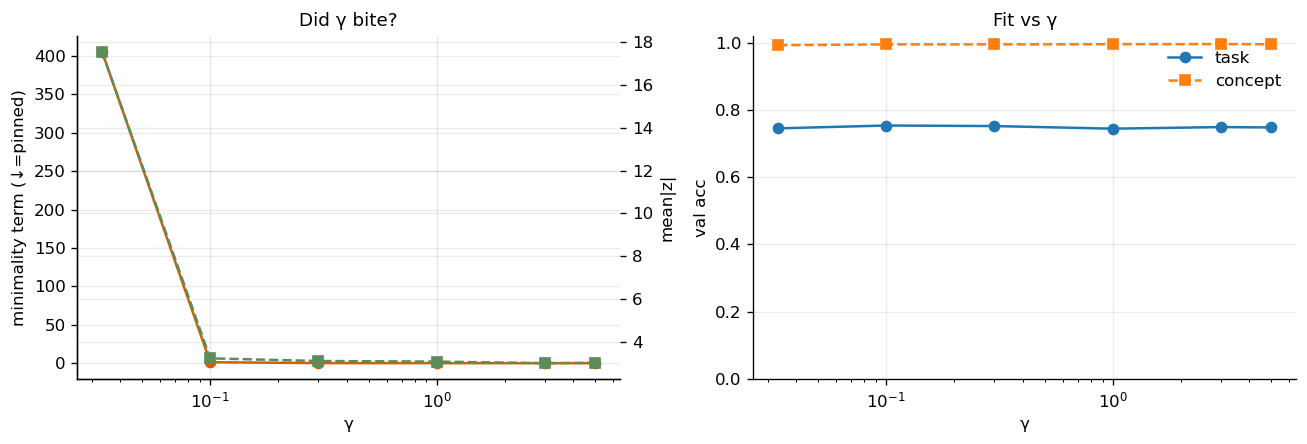

In [2]:
import torch
def zstats_seed(cfg, seed):
    pth = REPO/"external"/"minimal_cbm"/"results"/cfg/str(seed)/"predictions"/"epoch_100.pth"
    if not pth.exists(): return None
    d=torch.load(pth, map_location="cpu", weights_only=False); z,cc=d["z"].float(),d["c"].float()
    if not (np.isfinite(z).all() and np.isfinite(cc).all()): return None
    yp=d["y_preds"]; ta=float((yp.argmax(-1)==d["y"]).float().mean()) if yp.ndim>1 else float((yp==d["y"]).float().mean())
    cp=d["c_preds"]; cp=cp[...,0] if cp.ndim==3 else cp
    return float(((6*cc-3-z)**2).mean()), float(z.abs().mean()), ta, float(((cp>=0.5).float()==cc).float().mean())
rows=[]
for g,tag in [(0,"g0"),(0.1,"g0p1"),(0.3,"g0p3"),(1,"g1"),(3,"g3"),(5,"g5")]:
    for seed in range(1,6):
        s=zstats_seed(f"funnybirds-mcbm-{tag}", seed)
        if s: rows.append((g,seed,*s))
if rows:
    D=pd.DataFrame(rows,columns=["gamma","seed","rep_loss","mean_abs_z","task_acc","concept_acc"])
    Dg=D.groupby("gamma").agg(rep_loss=("rep_loss","mean"),mean_abs_z=("mean_abs_z","mean"),
                              task_acc=("task_acc","mean"),concept_acc=("concept_acc","mean"),n_seeds=("seed","nunique")).reset_index()
    display(Dg.round(3)); floor=(Dg.gamma[Dg.gamma>0].min() or 0.05)/3
    fig,ax=plt.subplots(1,2,figsize=(11,3.8))
    ax[0].plot(Dg.gamma.replace(0,floor),Dg.rep_loss,"o-",color=MCBM_C,label="mean (±3−z)²")
    a0=ax[0].twinx(); a0.plot(Dg.gamma.replace(0,floor),Dg.mean_abs_z,"s--",color="#5B8C5A",label="mean|z|")
    ax[0].set_xscale("log"); ax[0].set_xlabel("γ"); ax[0].set_ylabel("minimality term (↓=pinned)"); a0.set_ylabel("mean|z|"); ax[0].set_title("Did γ bite?")
    ax[1].plot(Dg.gamma.replace(0,floor),Dg.task_acc,"o-",label="task"); ax[1].plot(Dg.gamma.replace(0,floor),Dg.concept_acc,"s--",label="concept")
    ax[1].set_xscale("log"); ax[1].set_xlabel("γ"); ax[1].set_ylabel("val acc"); ax[1].set_ylim(0,1.02); ax[1].legend(); ax[1].set_title("Fit vs γ")
    plt.tight_layout()
    print("SANITY CHECK: γ changed z strongly, mostly between 0 and 0.1. "
          "Grounding must now be tested; this plot alone is not a verdict.")


**What appeared.** The representation changes sharply between `γ=0` and `γ=0.1`, while concept and species accuracy remain similar. Little further compression occurs after `0.1`.

Therefore this experiment mainly compares minimality off with minimality on; it is not six evenly spaced compression levels. We now repeat the exact CBM swap test.


## 2 · Does the replacement concept beat the old concept?

For each part and `γ`, compute

`P(z_donor,cf − z_source,cf > 0)`.

If minimality creates grounding, tail replacement wins should rise toward the strong wing/foot controls. If tail remains low while those controls stay high, compression did not solve the input-source problem.


loaded swaps: {0.0: [1, 2, 3], 0.1: [1, 2, 3], 0.3: [1], 1.0: [1], 3.0: [1], 5.0: [1]}


part,tail,wing,beak,foot,eye
gamma,,,,,
0.0,0.342,0.832,0.561,0.855,0.541
0.1,0.229,0.835,0.575,0.939,0.607
0.3,0.160,0.856,0.564,0.924,0.585
1.0,0.259,0.860,0.747,0.918,0.519
3.0,0.202,0.872,0.748,0.952,0.572
5.0,0.195,0.866,0.724,0.950,0.725


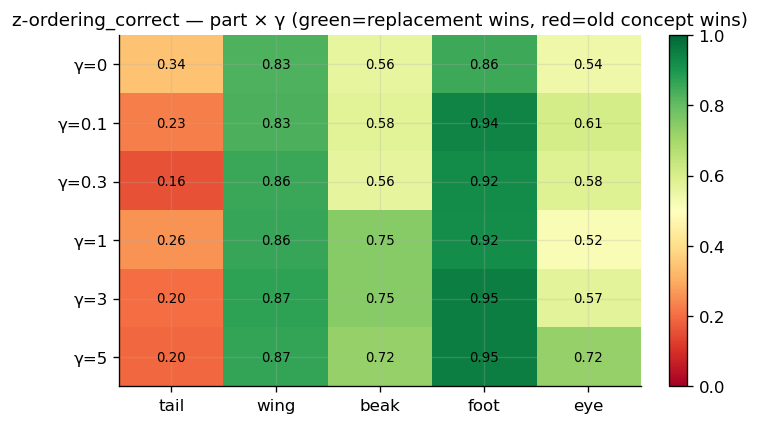

In [3]:
ORDER=["tail","wing","beak","foot","eye"]
def load_swaps():
    # load EVERY completed combined CSV across gamma AND seed (per-part files like
    # ...-s1-beak.csv are skipped by the strict regex; only ...-sN.csv match).
    rows=[]
    for fp in sorted(glob.glob(str(CURATED/"swap"/"funnybirds-mcbm-g*-s*.csv"))):
        m=re.match(r"funnybirds-mcbm-g([0-9p]+)-s(\d+)\.csv$", Path(fp).name)
        if not m: continue
        d=pd.read_csv(fp); d["gamma"]=float(m.group(1).replace("p",".")); d["seed"]=int(m.group(2)); rows.append(d)
    SW=pd.concat(rows,ignore_index=True) if rows else None
    cbs=[f for f in sorted(glob.glob(str(CURATED/"swap"/"funnybirds-cbm-s*.csv")))
         if re.match(r"funnybirds-cbm-s(\d+)\.csv$", Path(f).name)]
    CB=pd.concat([pd.read_csv(f) for f in cbs],ignore_index=True) if cbs else None
    if SW is not None:
        print("loaded swaps:", {g:sorted(SW[SW.gamma==g].seed.unique().tolist()) for g in sorted(SW.gamma.unique())})
    return SW, CB
SW,CB=load_swaps()
if SW is None:
    print("[pending] no MCBM swap CSVs -> CONFIG_PREFIX=funnybirds-mcbm GAMMAS=\"0 0.1 0.3 1 3 5\" sbatch train/renderer_swap.slurm")
else:
    H=SW.groupby(["gamma","part"]).ordering_correct.mean().unstack().reindex(columns=ORDER)
    display(H.round(3))
    fig,ax=plt.subplots(figsize=(6.2,3.8)); im=ax.imshow(H.values,cmap="RdYlGn",vmin=0,vmax=1,aspect="auto")
    ax.set_xticks(range(len(ORDER))); ax.set_xticklabels(ORDER)
    ax.set_yticks(range(len(H.index))); ax.set_yticklabels([f"γ={g:g}" for g in H.index])
    for i in range(H.shape[0]):
        for j in range(H.shape[1]):
            v=H.values[i,j]
            if np.isfinite(v): ax.text(j,i,f"{v:.2f}",ha="center",va="center",fontsize=8)
    ax.set_title("z-ordering_correct — part × γ (green=replacement wins, red=old concept wins)"); fig.colorbar(im,fraction=0.046)


**What appeared.** Tail remains poor for every tested `γ`; wing and foot remain strong. Beak and eye vary. Most settings above `γ=0.1` currently have one seed, so their differences are provisional.

The supported conclusion is that turning minimality on does not rescue tail grounding.


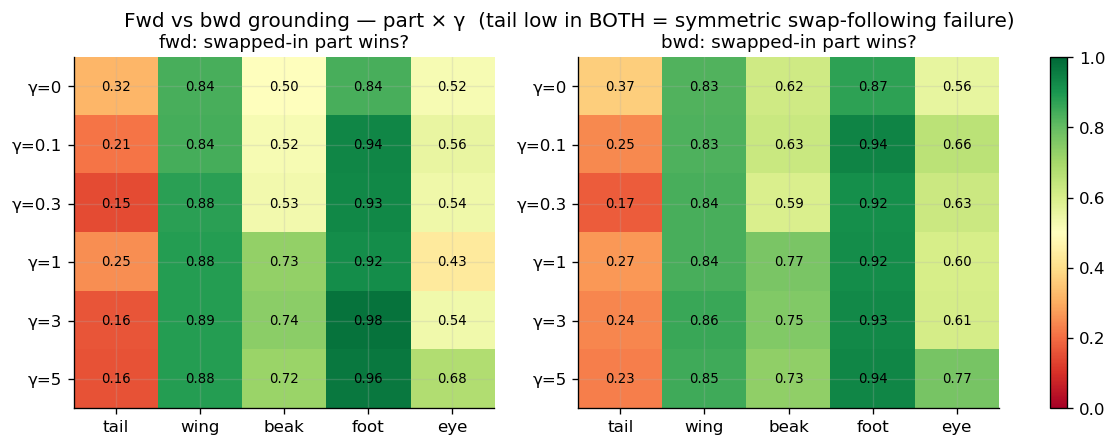

In [4]:
if SW is not None and "direction" in SW.columns:
    fig,axes=plt.subplots(1,2,figsize=(11,3.8)); last_im=None
    for ax,dirn in zip(axes,["fwd","bwd"]):
        H=SW[SW.direction==dirn].groupby(["gamma","part"]).ordering_correct.mean().unstack().reindex(columns=ORDER)
        last_im=ax.imshow(H.values,cmap="RdYlGn",vmin=0,vmax=1,aspect="auto")
        ax.set_xticks(range(len(ORDER))); ax.set_xticklabels(ORDER)
        ax.set_yticks(range(len(H.index))); ax.set_yticklabels([f"γ={g:g}" for g in H.index])
        for i in range(H.shape[0]):
            for j in range(H.shape[1]):
                v=H.values[i,j]
                if np.isfinite(v): ax.text(j,i,f"{v:.2f}",ha="center",va="center",fontsize=8)
        ax.set_title(f"{dirn}: swapped-in part wins?")
    fig.colorbar(last_im,ax=axes,fraction=0.046)
    fig.suptitle("Fwd vs bwd grounding — part × γ  (tail low in BOTH = symmetric swap-following failure)")
else: print("[pending] swap CSV with 'direction' column")


Forward and backward swaps agree. This rules against reversed bookkeeping. It establishes symmetric swap-following failure, not by itself a species-backwash mechanism.


### 2a · Coverage and direct donor response

First verify rows, parts, directions, seeds, and checkpoint coverage. Then separate raw donor movement from the old-vs-new ordering:

`donor_shift = z_donor,cf − z_donor,orig`.

Because minimality changes raw scale, also compute

`gap_closed = donor_shift / (z_source,orig − z_donor,orig)`.

`gap_closed=0.25` means the replacement closed 25% of its starting deficit. This test is inserted to determine whether a low tail margin is merely a smaller MCBM number scale or a genuinely weaker response relative to that model's own starting gap.


In [5]:
if SW is not None:
    coverage=(SW.groupby(["gamma","seed","part","direction"])
                .agg(rows=("margin","size"),source_species=("sid_src","nunique"),
                     donor_species=("sid_donor","nunique"),donor_variants=("var_donor","nunique")))
    display(coverage)
    req=["z_new","z_new_orig","z_old","z_old_orig","margin","ordering_correct"]
    print("missing values:",int(SW[[c for c in req if c in SW]].isna().sum().sum()))


rows  source_species  donor_species  donor_variants
gamma seed part direction                                                     
0.0   1    beak bwd         500              35             40               4
                fwd         500              40             35               4
           eye  bwd         500              39             38               3
                fwd         500              38             39               3
           foot bwd         500              38             38               4
...                         ...             ...            ...             ...
5.0   1    foot fwd         500              38             38               4
           tail bwd         500              38             37               9
                fwd         500              37             38               9
           wing bwd         500              39             36               6
                fwd         500              36             39               6

[100 rows x 4 columns]

missing values: 0


part                                            tail    wing    beak    foot  \
                                       gamma                                   
mean raw shift                         0.0    13.542  24.619  15.647  23.968   
                                       0.1     3.870  14.080   8.939  17.384   
                                       0.3     2.701  15.801  10.288  17.126   
                                       1.0     2.914  15.265   9.897  17.035   
                                       3.0     1.504  14.613   9.057  20.029   
                                       5.0     1.599  14.407   8.325  16.565   
median fraction of original gap closed 0.0     0.436   0.722   0.569   0.709   
                                       0.1     0.223   0.670   0.479   0.775   
                                       0.3     0.125   0.739   0.514   0.758   
                                       1.0     0.112   0.762   0.671   0.890   
                                       3.0     0.032   0.795   0.623   0.977   
                                       5.0     0.030   0.825   0.502   0.912   

part                                             eye  
                                       gamma          
mean raw shift                         0.0    16.275  
                                       0.1     8.750  
                                       0.3     9.470  
                                       1.0     7.561  
                                       3.0     6.740  
                                       5.0     8.179  
median fraction of original gap closed 0.0     0.600  
                                       0.1     0.520  
                                       0.3     0.586  
                                       1.0     0.457  
                                       3.0     0.394  
                                       5.0     0.580

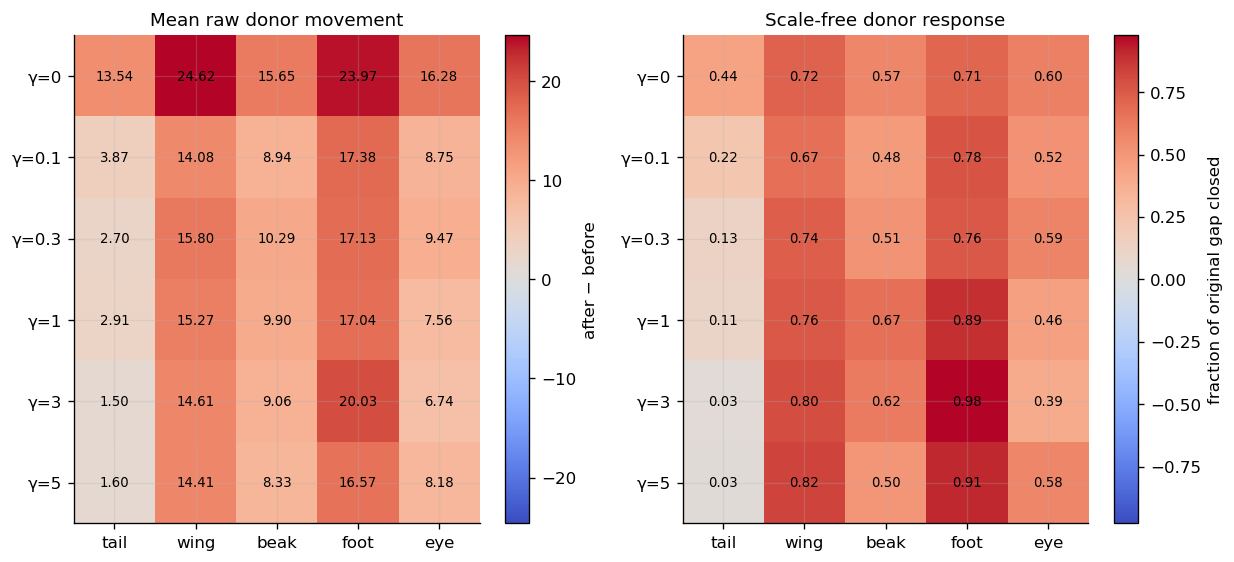

In [6]:
if SW is not None and {"z_new","z_new_orig","z_old_orig"}.issubset(SW.columns):
    d=SW.assign(donor_shift=SW.z_new-SW.z_new_orig,
                original_gap=SW.z_old_orig-SW.z_new_orig)
    d=d[d.original_gap>1e-6]
    d["gap_closed"]=d.donor_shift/d.original_gap
    raw=d.groupby(["gamma","part"]).donor_shift.mean().unstack().reindex(columns=ORDER)
    norm=d.groupby(["gamma","part"]).gap_closed.median().unstack().reindex(columns=ORDER)
    display(pd.concat({"mean raw shift":raw,"median fraction of original gap closed":norm},axis=0).round(3))
    fig,axes=plt.subplots(1,2,figsize=(12,0.58*len(raw)+1.8))
    specs=[(raw,"Mean raw donor movement","after − before"),(norm,"Scale-free donor response","fraction of original gap closed")]
    for ax,(q,title,label) in zip(axes,specs):
        lim=np.nanmax(np.abs(q.values)); im=ax.imshow(q.values,aspect="auto",cmap="coolwarm",vmin=-lim,vmax=lim)
        ax.set(xticks=range(len(q.columns)),xticklabels=q.columns,yticks=range(len(q.index)),yticklabels=[f"γ={g:g}" for g in q.index])
        for r in range(q.shape[0]):
            for k in range(q.shape[1]): ax.text(k,r,f"{q.iloc[r,k]:.2f}",ha="center",va="center",fontsize=8)
        ax.set_title(title); plt.colorbar(im,ax=ax,label=label)
    plt.show()


**What appeared.** Normalized tail response falls from about `0.44` at `γ=0` to about `0.03` at `γ=3–5`, while wing rises and foot remains strong. Therefore tail suppression is not only a raw-scale artifact.

This is compatible with minimality suppressing weak within-label tail variation while a stable body-based label route remains. It is not a complete mechanism proof because the same loss acts on every part.


### 2b · Seed support

Connected means can make one-seed noise look like a smooth `γ` trend. Plot every seed separately. A change is dependable only when it repeats across independently trained seeds.


gamma,0.0,0.1,0.3,1.0,3.0,5.0
seed,,,,,,
1,0.362,0.245,0.16,0.259,0.202,0.195
2,0.346,0.223,NaN,NaN,NaN,NaN
3,0.319,0.219,NaN,NaN,NaN,NaN


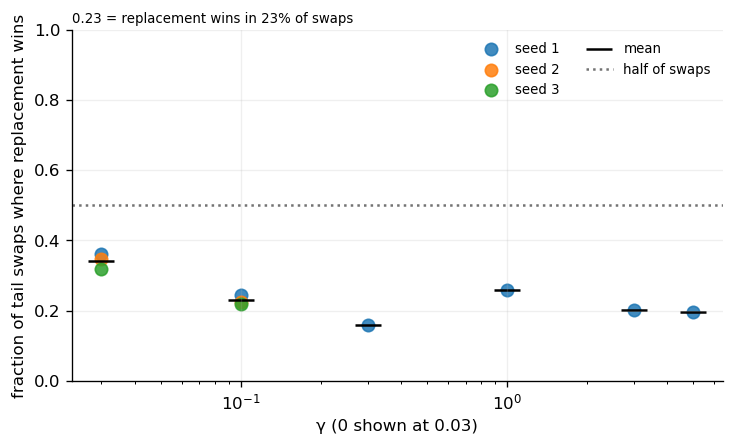

,mean,std,count
gamma,,,
0.0,0.342,0.022,3
0.1,0.229,0.014,3
0.3,0.160,NaN,1
1.0,0.259,NaN,1
3.0,0.202,NaN,1
5.0,0.195,NaN,1


In [7]:
if SW is not None:
    t=(SW[SW.part=="tail"].groupby(["gamma","seed"]).ordering_correct.mean().reset_index())
    display(t.pivot(index="seed",columns="gamma",values="ordering_correct").round(3))
    fig,ax=plt.subplots(figsize=(7,3.8))
    for seed,d in t.groupby("seed"):
        x=[g if g>0 else 0.03 for g in d.gamma]
        ax.scatter(x,d.ordering_correct,s=55,label=f"seed {seed}",alpha=.85)
    means=t.groupby("gamma").ordering_correct.agg(["mean","std","count"])
    x=[g if g>0 else 0.03 for g in means.index]
    ax.scatter(x,means["mean"],marker="_",s=260,color="black",label="mean")
    ax.axhline(.5,color="0.45",ls=":",label="half of swaps")
    ax.set_xscale("log"); ax.set_ylim(0,1); ax.set_xlabel("γ (0 shown at 0.03)")
    ax.set_ylabel("fraction of tail swaps where replacement wins")
    ax.text(0,1.02,"0.23 = replacement wins in 23% of swaps",transform=ax.transAxes,fontsize=8); ax.legend(ncol=2,fontsize=8)
    ax.grid(alpha=.2); plt.show()
    display(means.round(3))


**What appeared.** Three seeds support the drop from `γ=0` to `γ=0.1`. Higher values currently have one seed. Thus “minimality on did not rescue tail” is supported; a smooth monotonic dose-response claim must wait for the missing seeds.


## 3 · Visibility alternative under MCBM

Repeat the CBM visibility control using `pixel_count_cf`. Compare all tail swaps, visible-only tail swaps, and visible-only foot swaps.

If visible-only tail reaches foot, occlusion explains the failure. If it improves but remains far lower, visibility contributes without settling the remaining input source.


,tail_all,tail_visible,foot_visible(grounded)
gamma,,,
0.0,0.342,0.425,0.868
0.1,0.229,0.277,0.944
0.3,0.160,0.216,0.935
1.0,0.259,0.309,0.936
3.0,0.202,0.259,0.966
5.0,0.195,0.240,0.956


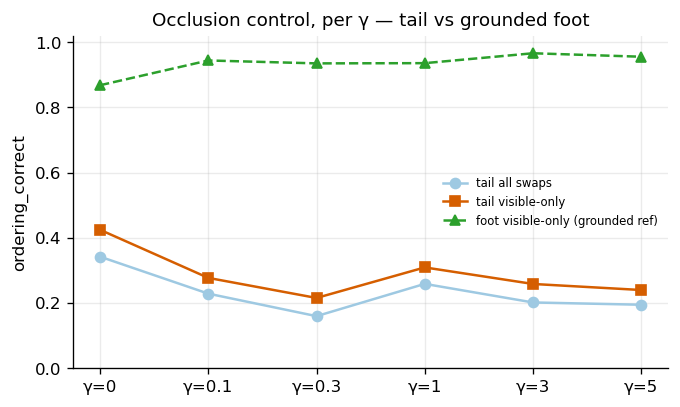

In [8]:
if SW is not None and "pixel_count_cf" in SW.columns:
    allg=SW[SW.part=="tail"].groupby("gamma").ordering_correct.mean()
    visg=SW[(SW.part=="tail")&(SW.pixel_count_cf>=50)].groupby("gamma").ordering_correct.mean()
    footv=SW[(SW.part=="foot")&(SW.pixel_count_cf>=50)].groupby("gamma").ordering_correct.mean()
    D=pd.DataFrame({"tail_all":allg,"tail_visible":visg,"foot_visible(grounded)":footv}); display(D.round(3))
    fig,ax=plt.subplots(figsize=(6.4,3.6)); x=np.arange(len(D))
    ax.plot(x,D["tail_all"],"o-",label="tail all swaps",color="#9ec9e2")
    ax.plot(x,D["tail_visible"],"s-",label="tail visible-only",color=MCBM_C)
    ax.plot(x,D["foot_visible(grounded)"],"^--",label="foot visible-only (grounded ref)",color="#2ca02c")
    ax.set_xticks(x); ax.set_xticklabels([f"γ={g:g}" for g in D.index]); ax.set_ylim(0,1.02)
    ax.set_ylabel("ordering_correct"); ax.legend(fontsize=7); ax.set_title("Occlusion control, per γ — tail vs grounded foot")
else: print("[pending] mcbm swap CSVs with pixel_count_cf")

**What appeared.** Visibility filtering improves tail at every `γ`, but tail remains far below foot. Test-time visibility is a partial explanation. Minimality changes `z`; it does not repair a training label that remains positive when tail pixels are hidden.


## 4 · Necessity check by deletion

Deletion measures

`retained_frac = p_removed / p_intact`.

This asks whether the old concept remains supported after its pixels disappear. It is weaker than a swap because it does not test which visible replacement wins, but agreement with the swap anomaly strengthens the claim that tail has unusual outside support.


tail retained_frac by γ (mean±std over seeds):


,gamma,mean,std
3,0.0,0.284,0.080
8,0.1,0.358,0.152
13,0.3,0.420,NaN
18,1.0,0.360,NaN
23,3.0,0.265,NaN
28,5.0,0.450,NaN


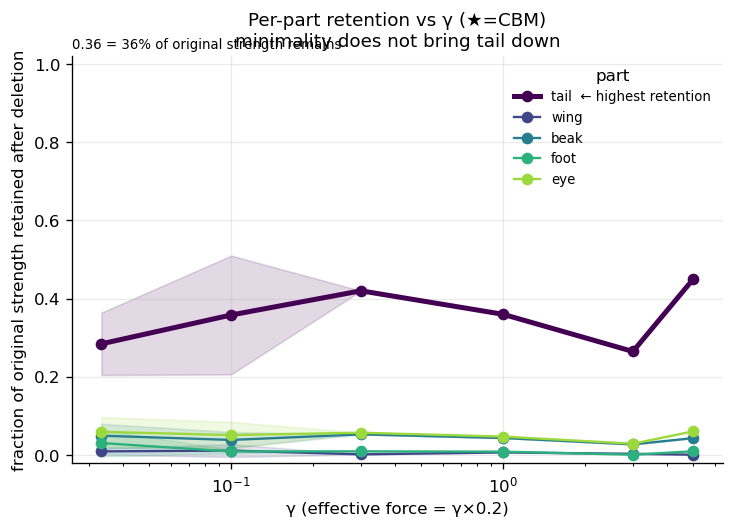

In [9]:
recs=[]
for f in sorted(glob.glob(str(CURATED/"grounding"/"funnybirds-*-s*.parquet"))):
    pr=parse_stem(Path(f).stem)
    if pr is None or pr[0]=="vanilla": continue
    model,gamma,seed=pr; d=pd.read_parquet(f)
    if "changed_frac" in d.columns: d=d[d["changed_frac"]>EPS]
    gg=d.groupby("part").agg(pi=("p_intact","mean"),pr=("p_removed","mean"))
    for part,row in gg.iterrows(): recs.append(dict(model=model,gamma=gamma,seed=seed,part=part,retained_frac=row.pr/row.pi))
P=pd.DataFrame(recs)
if len(P):
    parts=["tail","wing","beak","foot","eye"]
    A=P.groupby(["model","gamma","part"]).retained_frac.agg(["mean","std"]).reset_index()
    mc=A[A.model=="mcbm"]; cbm_pp=A[A.model=="cbm"].set_index("part")["mean"]
    floor=(mc.gamma[mc.gamma>0].min() or 0.05)/3
    fig,ax=plt.subplots(figsize=(7,4.4)); cmap=plt.cm.viridis(np.linspace(0,0.85,len(parts)))
    for part,col in zip(parts,cmap):
        s=mc[mc.part==part].sort_values("gamma");
        if not len(s): continue
        x=s.gamma.replace(0,floor)
        ax.plot(x,s["mean"],"o-",color=col,lw=3 if part=="tail" else 1.4,label=part+("  ← highest retention" if part=="tail" else ""))
        ax.fill_between(x, s["mean"]-s["std"].fillna(0), s["mean"]+s["std"].fillna(0), color=col, alpha=0.15)
        if part in cbm_pp.index: ax.scatter([floor/1.6],[cbm_pp[part]],marker="*",s=90,color=col,zorder=5)
    ax.set_xscale("log"); ax.set_xlabel("γ (effective force = γ×0.2)"); ax.set_ylabel("fraction of original strength retained after deletion")
    ax.text(0,1.02,"0.36 = 36% of original strength remains",transform=ax.transAxes,fontsize=8)
    ax.set_ylim(-0.02,1.02); ax.set_title("Per-part retention vs γ (★=CBM)\nminimality does not bring tail down"); ax.legend(title="part",fontsize=8)
    print("tail retained_frac by γ (mean±std over seeds):")
    display(mc[mc.part=="tail"][["gamma","mean","std"]].sort_values("gamma").round(3))
else: print("[pending] bash analysis/grounding_sweep.sh")


**What appeared.** Tail retains much more strength after deletion than other parts. The curve is noisy and mostly single-seed, so it supports a tail-specific problem but does not establish a smooth `γ` effect.

Deletion and swapping are not contradictory: deletion can lower `z_source`, insertion can raise `z_donor`, and the old source can still remain larger.


## 5 · Does minimality remove stored class information?

Predict species `y` from all reported concepts and from the tail block. This tests information available in the representation, not which pixels computed it.

The tail-only result must be compared with the true-tail-label baseline (approximately `9/50=0.18`), not only random species chance `1/50=0.02`. To measure conditional leakage, compare `species←Z_tail` against `species←C_tail,true` within each true tail variant.


,gamma,c,tail,chance
0,0.0,0.984,0.203,0.02
1,0.1,0.988,0.218,0.02
2,0.3,0.990,0.190,0.02
3,1.0,0.994,0.198,0.02
4,3.0,0.986,0.268,0.02
5,5.0,0.998,0.272,0.02


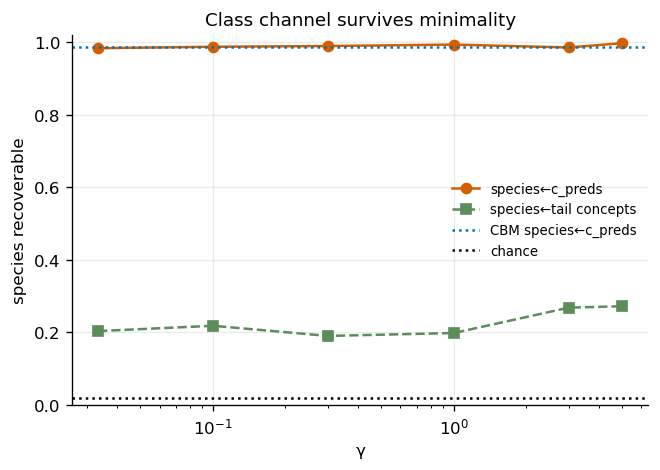

In [10]:
rows=[]
for f in sorted(glob.glob(str(CURATED/"species_probe"/"funnybirds-mcbm-g*-s*.json"))):
    m=re.search(r"-g([0-9p]+)-s(\d+)\.json$", Path(f).name)
    if not m: continue
    S=json.loads(Path(f).read_text())
    rows.append(dict(gamma=float(m.group(1).replace("p",".")), seed=int(m.group(2)),
                     c=S["species_from_cpreds"]["acc"], tail=S["species_from_part_cpreds"].get("tail",{}).get("acc",np.nan),
                     chance=S["chance"]))
if rows:
    D=pd.DataFrame(rows); Dg=D.groupby("gamma").agg(c=("c","mean"),tail=("tail","mean"),chance=("chance","first")).reset_index()
    display(Dg.round(3)); floor=(Dg.gamma[Dg.gamma>0].min() or 0.05)/3
    cbj=sorted(glob.glob(str(CURATED/"species_probe"/"funnybirds-cbm-s*.json")))
    fig,ax=plt.subplots(figsize=(6.2,4))
    ax.plot(Dg.gamma.replace(0,floor),Dg.c,"o-",color=MCBM_C,label="species←c_preds")
    ax.plot(Dg.gamma.replace(0,floor),Dg["tail"],"s--",color="#5B8C5A",label="species←tail concepts")
    if cbj: ax.axhline(np.mean([json.loads(Path(p).read_text())["species_from_cpreds"]["acc"] for p in cbj]),ls=":",color=CBM_C,label="CBM species←c_preds")
    ax.axhline(Dg.chance.iloc[0],ls=":",color="k",label="chance"); ax.set_xscale("log")
    ax.set_xlabel("γ"); ax.set_ylabel("species recoverable"); ax.set_ylim(0,1.02); ax.legend(fontsize=8)
    ax.set_title("Class channel survives minimality")
else: print("[pending] grounding_sweep.sh runs the probe too")

**What appeared.** The full concept vector still predicts species almost perfectly. Tail-only accuracy is only modestly above its label-only baseline at some settings and lacks full seed coverage.

This does not prove tail backwash. More importantly, even perfect MCBM compression could hide a body-based OR-over-species computation by mapping every route to the same `±3` output.


## 6 · Does the concept change influence the species head?

Plot task-head response against tail `margin`. This asks whether a larger donor-tail victory affects species probability. It is not a direct harm metric because a one-tail replacement does not make the whole bird belong to the donor species.


,rows,mean_P_donor,P_donor_above_.5,P_donor_above_.9
model,,,,
MCBM γ=0,3000,0.0395,0.0397,0.030
CBM,1000,0.0127,0.0100,0.006


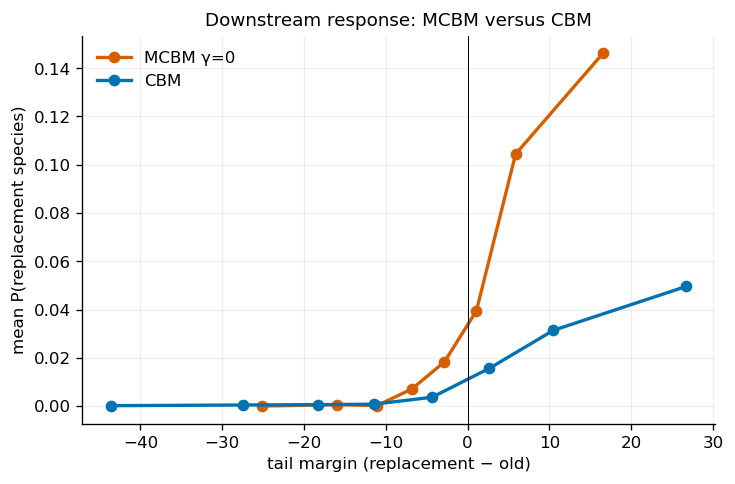

P(donor)>.5 is only a proxy for donor dominance; exact class-flip rate requires saving predicted_class in future CSVs.


In [11]:
if SW is not None and "p_cf_donor" in SW.columns:
    fig,ax=plt.subplots(figsize=(6.8,4.2))
    series=[]
    g0=sorted(SW.gamma.unique())[0]
    series.append((f"MCBM γ={g0:g}",SW[(SW.part=="tail")&(SW.gamma==g0)].copy(),MCBM_C))
    if CB is not None: series.append(("CBM",CB[CB.part=="tail"].copy(),CBM_C))
    summary=[]
    for label,t,col in series:
        if len(t)>8:
            t["mb"]=pd.qcut(t.margin,8,duplicates="drop")
            gb=t.groupby("mb",observed=True).agg(mx=("margin","mean"),my=("p_cf_donor","mean"))
            ax.plot(gb.mx,gb.my,"o-",lw=2,label=label,color=col)
        summary.append({"model":label,"rows":len(t),"mean_P_donor":t.p_cf_donor.mean(),
                        "P_donor_above_.5":(t.p_cf_donor>.5).mean(),"P_donor_above_.9":(t.p_cf_donor>.9).mean()})
    display(pd.DataFrame(summary).set_index("model").round(4))
    ax.axvline(0,color="k",lw=.6); ax.set(xlabel="tail margin (replacement − old)",ylabel="mean P(replacement species)",title="Downstream response: MCBM versus CBM")
    ax.legend(); ax.grid(alpha=.2); plt.show()
    print("P(donor)>.5 is only a proxy for donor dominance; exact class-flip rate requires saving predicted_class in future CSVs.")
else: print("[pending] swap CSV with p_cf_donor")


**What appeared.** Donor-species probability rises modestly as the donor tail wins. The demonstrated failure remains at the concept/explanation level; this graph does not show widespread classification damage.


## 7 · Conclusion and decisive next experiment

Current MCBM runs establish:

1. `γ` compresses `z` without destroying ordinary accuracy.
2. Compression does not guarantee that a concept follows its named pixels.
3. Tail's normalized donor response becomes much smaller when minimality is on.
4. Wing and foot remain grounded controls.
5. Visibility explains only part of the tail gap.

Minimality controls **what remains in `z_j` after the answer is formed**. It does not control **which pixels formed the answer**.

The decisive grounding design independently varies part identity `T` and body/species `B`:

`z_tail = f(T,B)`.

Hold `T` fixed and change only `B`; any systematic change in `z_tail` is a causal non-tail effect. Hold `B` fixed and change only `T`; this is the intended tail effect. Repeat for every output slot to detect tail→beak/wing/eye/foot spillover.

Relabelled training then tests why the effect arose. The same relabeling idea can and should be applied to a standard CBM as well as MCBM; comparing CBM vs CBM-RL isolates the data-label change without the minimality term.


## Provenance

The swap, direction, visibility, compression, seed, deletion, probe, and downstream ideas come from the complete original MCBM renderer notebook. They are reordered here so each test states its variables and decision rule before showing the result.
